in this we are ignoring car model column and assuming them all to be of same comapny and model

In [183]:
import pandas as pd
df = pd.read_csv("carprices.csv")
df.head() # by default shows top 5 values

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


In [184]:
import matplotlib.pyplot as plt
%matplotlib inline


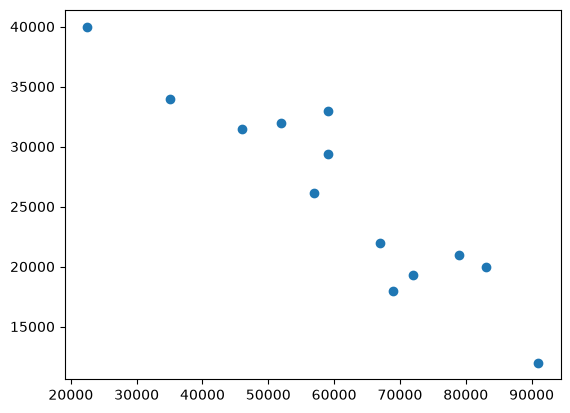

In [185]:
plt.scatter(df['Mileage'],df['Sell Price($)'])

checked linear relation

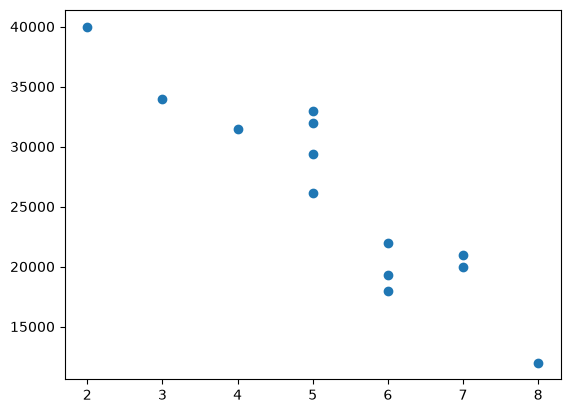

In [186]:
plt.scatter(df['Age(yrs)'],df['Sell Price($)'])

In [187]:
X = df[['Mileage','Age(yrs)']]

In [188]:
y = df['Sell Price($)']

In [189]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1) 

here 10% of data is used for testing and rest 90% for training

everytime you run it , it selects random 70% i.e. 9 numbers for training.  Now if you want the training data to be a fixed set of 11 numbers then write
- train_test_split(X,y,test_size=0.1, random_state = 10) # here 10 is representing that the randomly generated 10th dataset to be used for training. It could have been any other number also

The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model.

In [190]:
len(X_train)

11

In [191]:
X_train

,Mileage,Age(yrs)
4,46000,4
12,59000,5
9,67000,6
8,91000,8
11,79000,7
2,57000,5
5,59000,5
6,52000,5
1,35000,3
10,83000,7


In [192]:
y_train

4     31500
12    33000
9     22000
8     12000
11    21000
2     26100
5     29400
6     32000
1     34000
10    20000
0     18000
Name: Sell Price($), dtype: int64

In [193]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -0.19,-2371.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Mileage','Age(yrs)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.043e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [194]:
X_test

,Mileage,Age(yrs)
7,72000,6
3,22500,2


In [195]:
clf.predict(X_test)

array([22661.82397601, 41454.95829037])

In [196]:
y_test

7    19300
3    40000
Name: Sell Price($), dtype: int64

In [197]:
clf.score(X_test, y_test)

0.9373672007637438